# 노후 시설물 중복 신고 매칭 시스템 (YOLO + SIFT)

YOLO로 시설물을 탐지하고, 해당 영역만 잘라서 SIFT로 매칭하여 같은 개체인지 판정.

## 핵심 흐름
```
사진 업로드
  ↓
YOLO 탐지 (confidence 최고 1개 선택)
  ↓
Damaged 클래스인가? → No면 신고 거부
  ↓
bbox로 영역 크롭
  ↓
같은 facility_type의 기존 그룹들과만 SIFT 매칭
  ↓
매칭 성공 → 기존 그룹 합류, report_count +1
매칭 실패 → 새 group_id 생성 (이 이미지가 대표)
```

## 정책
- **Damaged 클래스만 접수** (Normal이 탐지되면 거부)
- 한 사진에 여러 물체 탐지되면 **confidence 최고 1개만** 처리
- 매칭 대상: **같은 facility_type의 대표 이미지들만**
- GPS는 현재 미사용 (컬럼만 준비, 추후 확장)

## 1. 환경 설정

필요한 패키지:
- `opencv-python` (이미지 처리)
- `numpy`, `matplotlib`
- `ultralytics` (YOLO)
- SQLite는 표준 라이브러리

YOLO 충돌이 자주 나면 **별도 conda 환경** 권장:
```bash
conda create -n yolo_env python=3.11 -y
conda activate yolo_env
pip install ultralytics opencv-python matplotlib jupyter ipykernel
python -m ipykernel install --user --name yolo_env
```

In [45]:
# 패키지 확인 (없으면 주석 해제해서 설치)
# !pip install ultralytics opencv-python matplotlib

import os
import sqlite3
import shutil
from datetime import datetime
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

print(f"OpenCV     : {cv2.__version__}")
print(f"NumPy      : {np.__version__}")

import ultralytics
print(f"Ultralytics: {ultralytics.__version__}")

OpenCV     : 4.10.0
NumPy      : 2.4.4
Ultralytics: 8.4.41


## 2. 경로 및 설정

- `BEST_PT_PATH`: YOLO 모델 파일 경로 (본인 경로로 수정)
- `BASE_DIR`: 프로젝트 데이터 저장 위치
- 매칭/판정 임계값들

In [ ]:
# === 경로 설정 ===

BEST_PT_PATH = ""

BASE_DIR    = Path("")
IMAGE_DIR   = BASE_DIR / "images"
CROP_DIR    = BASE_DIR / "crops"     # YOLO로 잘라낸 이미지
FEATURE_DIR = BASE_DIR / "features"
DB_PATH     = BASE_DIR / "facility.db"

for d in (IMAGE_DIR, CROP_DIR, FEATURE_DIR):
    d.mkdir(parents=True, exist_ok=True)

# === 매칭 파라미터 ===
YOLO_CONF_THRESHOLD = 0.4     # YOLO 탐지 최소 confidence
RATIO_THRESHOLD     = 0.75    # Lowe's ratio test
MIN_MATCH_COUNT     = 4       # RANSAC 최소 매칭 수
INLIER_THRESHOLD    = 15      # 같은 개체 판정 inlier 최소 개수

print(f"BASE_DIR       : {BASE_DIR.resolve()}")
print(f"BEST_PT_PATH   : {BEST_PT_PATH}")
print(f"YOLO confidence: {YOLO_CONF_THRESHOLD}")
print(f"INLIER 임계값  : {INLIER_THRESHOLD}")

BASE_DIR       : /home/piai/바탕화면/Feature_Matching
BEST_PT_PATH   : /home/piai/바탕화면/Feature_Matching/best.pt
YOLO confidence: 0.4
INLIER 임계값  : 15


## 3. 데이터베이스 스키마

### `facility_groups` (시설물 그룹)
| 컬럼 | 설명 |
|---|---|
| group_id | 그룹 ID (자동) |
| facility_type | 시설물 종류 (예: `BenchWithBack`) — **상태는 빼고** |
| report_count | 누적 신고 수 |
| damaged_count | Damaged 판정 건수 |
| created_at, updated_at | 타임스탬프 |

### `reports` (개별 신고)
| 컬럼 | 설명 |
|---|---|
| report_id | 신고 ID |
| group_id | 속한 그룹 |
| image_path | 원본 이미지 경로 |
| crop_path | YOLO 크롭 이미지 경로 |
| descriptor_path | SIFT descriptor .npy 경로 |
| keypoints_path | SIFT keypoint .npy 경로 |
| facility_type | 탐지된 종류 (BenchWithBack 등) |
| status | Normal / Damaged |
| detection_conf | YOLO confidence |
| bbox_x1,y1,x2,y2 | YOLO 박스 좌표 |
| lat, lng | GPS (nullable, 추후) |
| is_representative | 대표 이미지 여부 |
| uploaded_at | 업로드 시각 |

In [47]:
def init_db(db_path: Path = DB_PATH):
    """DB와 테이블 초기화. 이미 있으면 유지."""
    conn = sqlite3.connect(db_path)
    cur = conn.cursor()

    cur.execute("""
        CREATE TABLE IF NOT EXISTS facility_groups (
            group_id       INTEGER PRIMARY KEY AUTOINCREMENT,
            facility_type  TEXT NOT NULL,
            report_count   INTEGER NOT NULL DEFAULT 0,
            damaged_count  INTEGER NOT NULL DEFAULT 0,
            created_at     TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
            updated_at     TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        )
    """)

    cur.execute("""
        CREATE TABLE IF NOT EXISTS reports (
            report_id         INTEGER PRIMARY KEY AUTOINCREMENT,
            group_id          INTEGER NOT NULL,
            image_path        TEXT NOT NULL,
            crop_path         TEXT NOT NULL,
            descriptor_path   TEXT NOT NULL,
            keypoints_path    TEXT NOT NULL,
            facility_type     TEXT NOT NULL,
            status            TEXT NOT NULL,
            detection_conf    REAL,
            bbox_x1           INTEGER,
            bbox_y1           INTEGER,
            bbox_x2           INTEGER,
            bbox_y2           INTEGER,
            lat               REAL,
            lng               REAL,
            is_representative INTEGER NOT NULL DEFAULT 0,
            uploaded_at       TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
            FOREIGN KEY (group_id) REFERENCES facility_groups(group_id)
        )
    """)

    cur.execute("CREATE INDEX IF NOT EXISTS idx_reports_group ON reports(group_id)")
    cur.execute("CREATE INDEX IF NOT EXISTS idx_groups_type ON facility_groups(facility_type)")

    conn.commit()
    conn.close()
    print("DB initialized.")


def reset_all():
    """모든 데이터 초기화 (디버깅용)."""
    if BASE_DIR.exists():
        shutil.rmtree(BASE_DIR)
    for d in (IMAGE_DIR, CROP_DIR, FEATURE_DIR):
        d.mkdir(parents=True, exist_ok=True)
    init_db()
    print("All data reset.")


init_db()

DB initialized.


## 4. YOLO 모델 로드 & 탐지 함수

`confidence 가장 높은 1개 물체`만 반환한다.

In [48]:
# === YOLO 모델 로드 ===
yolo_model = YOLO(BEST_PT_PATH)
print(f"클래스 개수: {len(yolo_model.names)}")
print(f"클래스 목록: {yolo_model.names}")


def parse_class_name(class_name):
    """
    'BenchWithBack_Damaged' → ('BenchWithBack', 'Damaged')
    """
    if "_" in class_name:
        facility_type, status = class_name.rsplit("_", 1)
        return facility_type, status
    return class_name, "Unknown"


# ============================================
# detect_main_object: OBB 대응 + Damaged 필터 제거
# ============================================
def detect_main_object(image_path, conf_threshold=YOLO_CONF_THRESHOLD, imgsz=960):
    """OBB YOLO 탐지. confidence 최고 1개 반환 (Normal/Damaged 모두)."""
    results = yolo_model(str(image_path), conf=conf_threshold, 
                         imgsz=imgsz, verbose=False)
    
    if not results:
        return None
    
    obb = results[0].obb
    if obb is None or len(obb) == 0:
        return None
    
    confidences = obb.conf.cpu().numpy()
    best_idx = int(np.argmax(confidences))
    
    cls_id = int(obb.cls[best_idx].item())
    conf = float(confidences[best_idx])
    
    # 회전 박스 → 축 정렬 박스 변환
    xyxyxyxy = obb.xyxyxyxy[best_idx].cpu().numpy()
    x1, y1 = int(xyxyxyxy[:, 0].min()), int(xyxyxyxy[:, 1].min())
    x2, y2 = int(xyxyxyxy[:, 0].max()), int(xyxyxyxy[:, 1].max())
    
    class_name = yolo_model.names[cls_id]
    facility_type, status = parse_class_name(class_name)
    
    return {
        "class_name":    class_name,
        "facility_type": facility_type,
        "status":        status,
        "confidence":    conf,
        "bbox":          (x1, y1, x2, y2),
        "obb_points":    xyxyxyxy.astype(int),
    }


클래스 개수: 22
클래스 목록: {0: 'BenchWithBack_Normal', 1: 'BenchWithBack_Damaged', 2: 'BenchWithoutBack_Normal', 3: 'BenchWithoutBack_Damaged', 4: 'ProtectionFence_Normal', 5: 'ProtectionFence_Damaged', 6: 'Bollard_Normal', 7: 'Bollard_Damaged', 8: 'JaywalkPrevention_Normal', 9: 'JaywalkPrevention_Damaged', 10: 'TreeCover_Normal', 11: 'TreeCover_Damaged', 12: 'Manhole_Normal', 13: 'Manhole_Damaged', 14: 'Trench_Normal', 15: 'Trench_Damaged', 16: 'CurbStone_Normal', 17: 'CurbStone_Damaged', 18: 'SidewalkBlock_Normal', 19: 'SidewalkBlock_Damaged', 20: 'BrailleBlock_Normal', 21: 'BrailleBlock_Damaged'}


## 5. SIFT 특징점 추출 (크롭된 영역에서)

YOLO로 잘라낸 영역에서 SIFT 특징점을 추출. CLAHE로 전처리까지 포함.

In [49]:
# === SIFT 설정 ===
SIFT_DETECTOR = cv2.SIFT_create(nfeatures=3000)


def preprocess_crop(crop_bgr, max_size=1024):
    """크롭된 BGR 이미지 → 리사이즈 + 그레이 + CLAHE."""
    h, w = crop_bgr.shape[:2]
    scale = max_size / max(h, w)
    if scale < 1.0:
        new_w, new_h = int(w * scale), int(h * scale)
        crop_bgr = cv2.resize(crop_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)
    return gray


def extract_features_from_crop(crop_bgr):
    """크롭 이미지에서 SIFT feature 추출."""
    gray = preprocess_crop(crop_bgr)
    keypoints, descriptors = SIFT_DETECTOR.detectAndCompute(gray, None)
    
    if descriptors is None or len(keypoints) == 0:
        return np.empty((0, 2), dtype=np.float32), np.empty((0, 128), dtype=np.float32)
    
    keypoints_xy = np.array([kp.pt for kp in keypoints], dtype=np.float32)
    return keypoints_xy, descriptors


def crop_image_by_bbox(image_path, bbox):
    """원본 이미지에서 bbox 영역만 잘라 반환 (BGR)."""
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"이미지 로드 실패: {image_path}")
    x1, y1, x2, y2 = bbox
    # 경계 안전 처리
    h, w = img.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)
    if x2 <= x1 or y2 <= y1:
        raise ValueError(f"bbox가 비정상: {bbox}")
    return img[y1:y2, x1:x2]

## 6. Feature 저장/로드

In [50]:
def save_features(report_id, keypoints_xy, descriptors):
    """feature를 .npy로 저장."""
    des_path = FEATURE_DIR / f"report_{report_id:04d}_des.npy"
    kp_path  = FEATURE_DIR / f"report_{report_id:04d}_kp.npy"
    np.save(des_path, descriptors)
    np.save(kp_path, keypoints_xy)
    return str(des_path), str(kp_path)


def load_features(des_path, kp_path):
    """feature 로드."""
    descriptors  = np.load(des_path)
    keypoints_xy = np.load(kp_path)
    return keypoints_xy, descriptors

## 7. 매칭 함수

SIFT는 float descriptor → L2 distance + BFMatcher.
Lowe's ratio test + RANSAC 기하 검증.

In [51]:
# SIFT용 매처 (L2 distance)
BF_MATCHER = cv2.BFMatcher(cv2.NORM_L2)


def match_features(kp1, des1, kp2, des2,
                   ratio=RATIO_THRESHOLD,
                   min_match=MIN_MATCH_COUNT):
    """두 feature 세트를 매칭 + RANSAC 기하 검증."""
    result = {
        "inliers": 0,
        "good_matches": 0,
        "total_kp1": len(kp1),
        "total_kp2": len(kp2),
        "homography": None,
        "match_obj": [],
    }

    if des1 is None or des2 is None or len(des1) < 2 or len(des2) < 2:
        return result

    knn_matches = BF_MATCHER.knnMatch(des1, des2, k=2)

    good = []
    for match_pair in knn_matches:
        if len(match_pair) < 2:
            continue
        m, n = match_pair
        if m.distance < ratio * n.distance:
            good.append(m)

    result["good_matches"] = len(good)
    result["match_obj"]    = good

    if len(good) < min_match:
        return result

    src_pts = np.float32([kp1[m.queryIdx] for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx] for m in good]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    if mask is not None:
        result["inliers"]    = int(mask.sum())
        result["homography"] = H

    return result


def is_same_facility(match_result, threshold=INLIER_THRESHOLD):
    return match_result["inliers"] >= threshold

## 8. DB 헬퍼 함수

In [52]:
def db_connect():
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    return conn


def create_new_group(facility_type):
    """새 그룹을 facility_type과 함께 생성."""
    with db_connect() as conn:
        cur = conn.cursor()
        cur.execute(
            "INSERT INTO facility_groups (facility_type, report_count) VALUES (?, 0)",
            (facility_type,)
        )
        return cur.lastrowid


def insert_report(group_id, image_path, crop_path, des_path, kp_path,
                  facility_type, status, detection_conf, bbox,
                  lat=None, lng=None, is_representative=0):
    with db_connect() as conn:
        cur = conn.cursor()
        cur.execute("""
            INSERT INTO reports
                (group_id, image_path, crop_path, descriptor_path, keypoints_path,
                 facility_type, status, detection_conf,
                 bbox_x1, bbox_y1, bbox_x2, bbox_y2,
                 lat, lng, is_representative)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (group_id, str(image_path), str(crop_path), des_path, kp_path,
              facility_type, status, detection_conf,
              bbox[0], bbox[1], bbox[2], bbox[3],
              lat, lng, is_representative))
        return cur.lastrowid


def update_report_paths(report_id, image_path, crop_path, des_path, kp_path):
    with db_connect() as conn:
        conn.execute("""
            UPDATE reports
               SET image_path=?, crop_path=?, descriptor_path=?, keypoints_path=?
             WHERE report_id=?
        """, (str(image_path), str(crop_path), des_path, kp_path, report_id))


def increment_group_count(group_id, status):
    """그룹 신고수 +1, Damaged면 damaged_count도 +1."""
    damaged_inc = 1 if status == "Damaged" else 0
    with db_connect() as conn:
        conn.execute("""
            UPDATE facility_groups
               SET report_count  = report_count + 1,
                   damaged_count = damaged_count + ?,
                   updated_at    = CURRENT_TIMESTAMP
             WHERE group_id = ?
        """, (damaged_inc, group_id))


def get_representatives_by_type(facility_type):
    """같은 facility_type의 대표 이미지들만 조회 (매칭 후보)."""
    with db_connect() as conn:
        rows = conn.execute("""
            SELECT r.report_id, r.group_id, r.crop_path,
                   r.descriptor_path, r.keypoints_path
              FROM reports r
              JOIN facility_groups g ON r.group_id = g.group_id
             WHERE r.is_representative = 1
               AND g.facility_type = ?
        """, (facility_type,)).fetchall()
    return [dict(r) for r in rows]


def get_group_summary():
    with db_connect() as conn:
        rows = conn.execute("""
            SELECT g.group_id, g.facility_type, g.report_count, g.damaged_count,
                   g.created_at
              FROM facility_groups g
             ORDER BY g.group_id
        """).fetchall()
    return [dict(r) for r in rows]

## 9. 메인 파이프라인

### 처리 단계
1. YOLO 탐지 → confidence 최고 1개
2. 탐지 실패 → **신고 거부**
3. Normal 판정 → **신고 거부**
4. Damaged 판정 → 계속 진행
5. bbox로 크롭
6. 같은 `facility_type`의 대표 이미지들과 매칭
7. inlier ≥ 임계값 → 기존 그룹 합류
8. 아니면 → 새 그룹 생성 (이 이미지가 대표)

In [53]:
# ============================================
# process_new_report: Damaged 필터 제거 버전
# ============================================
def process_new_report(input_image_path, lat=None, lng=None,
                       inlier_threshold=INLIER_THRESHOLD, verbose=True):
    """
    새 신고 처리. Damaged 필터 비활성화 상태.
    (나중에 추가하려면 아래 주석 처리된 블록을 다시 풀면 됨)
    """
    input_image_path = Path(input_image_path)
    if not input_image_path.exists():
        raise FileNotFoundError(input_image_path)

    # --- 1. YOLO 탐지 ---
    detection = detect_main_object(input_image_path)
    
    if detection is None:
        if verbose:
            print("[REJECTED] 물체를 찾지 못했습니다.")
        return {"status": "rejected", "reason": "object_not_detected"}
    
    if verbose:
        print(f"[YOLO] {detection['class_name']} "
              f"(conf={detection['confidence']:.2f}, bbox={detection['bbox']})")
    
    # --- 2. Damaged 필터 (임시 비활성화) ---
    # if detection["status"] != "Damaged":
    #     return {"status": "rejected", "reason": "not_damaged"}
    
    # --- 3. 크롭 & SIFT feature 추출 ---
    crop_bgr = crop_image_by_bbox(input_image_path, detection["bbox"])
    kp_new, des_new = extract_features_from_crop(crop_bgr)
    
    if verbose:
        print(f"[SIFT] 크롭 영역에서 {len(kp_new)}개 특징점 추출")
    
    # --- 4. 같은 facility_type의 대표들과 매칭 ---
    facility_type = detection["facility_type"]
    representatives = get_representatives_by_type(facility_type)
    
    if verbose:
        print(f"[DB] {facility_type} 타입 기존 그룹 {len(representatives)}개")
    
    best_match = {"inliers": 0, "group_id": None, "report_id": None}
    
    for rep in representatives:
        kp_ref, des_ref = load_features(rep["descriptor_path"], rep["keypoints_path"])
        m = match_features(kp_new, des_new, kp_ref, des_ref)
        
        if verbose:
            print(f"  vs report_{rep['report_id']:04d} (group {rep['group_id']}): "
                  f"good={m['good_matches']}, inliers={m['inliers']}")
        
        if m["inliers"] > best_match["inliers"]:
            best_match = {
                "inliers":   m["inliers"],
                "group_id":  rep["group_id"],
                "report_id": rep["report_id"],
            }
    
    # --- 5. 판정 ---
    is_new_group = best_match["inliers"] < inlier_threshold
    
    if is_new_group:
        group_id = create_new_group(facility_type)
        if verbose:
            print(f"[NEW GROUP] facility_type={facility_type}, group_id={group_id}")
    else:
        group_id = best_match["group_id"]
        if verbose:
            print(f"[MATCH] group_id={group_id} (inliers={best_match['inliers']})")
    
    # --- 6. report INSERT ---
    report_id = insert_report(
        group_id=group_id,
        image_path=str(input_image_path),
        crop_path="PENDING",
        des_path="PENDING",
        kp_path="PENDING",
        facility_type=facility_type,
        status=detection["status"],
        detection_conf=detection["confidence"],
        bbox=detection["bbox"],
        lat=lat, lng=lng,
        is_representative=1 if is_new_group else 0,
    )
    
    # --- 7. 파일 저장 ---
    ext = input_image_path.suffix
    final_img_path  = IMAGE_DIR / f"report_{report_id:04d}{ext}"
    final_crop_path = CROP_DIR  / f"report_{report_id:04d}_crop.jpg"
    
    shutil.copy2(input_image_path, final_img_path)
    cv2.imwrite(str(final_crop_path), crop_bgr)
    des_path, kp_path = save_features(report_id, kp_new, des_new)
    update_report_paths(report_id, final_img_path, final_crop_path, des_path, kp_path)
    
    # --- 8. 그룹 카운트 증가 ---
    increment_group_count(group_id, detection["status"])
    
    return {
        "status":            "accepted",
        "report_id":         report_id,
        "group_id":          group_id,
        "facility_type":     facility_type,
        "detection_status":  detection["status"],
        "detection_conf":    detection["confidence"],
        "is_new_group":      is_new_group,
        "best_inliers":      best_match["inliers"],
        "matched_report_id": None if is_new_group else best_match["report_id"],
    }

## 10. 시각화 유틸

- `visualize_detection()`: YOLO 박스만 시각화
- `visualize_match_crops()`: 두 크롭 이미지의 매칭선 시각화
- `print_db_status()`: 현재 DB 상태 요약

In [54]:
def visualize_detection(image_path):
    """OBB 탐지 결과 시각화."""
    detection = detect_main_object(image_path)
    img = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 7))
    plt.imshow(img_rgb)
    
    if detection:
        color = "red" if detection["status"] == "Damaged" else "green"
        
        # OBB 회전 박스 그리기 (4 꼭짓점 연결)
        if "obb_points" in detection:
            points = detection["obb_points"]
            # 4 꼭짓점을 폴리곤으로 연결
            polygon = plt.Polygon(points, fill=False, 
                                   edgecolor=color, linewidth=3)
            plt.gca().add_patch(polygon)
        
        # AABB도 점선으로 표시 (실제 크롭되는 영역)
        x1, y1, x2, y2 = detection["bbox"]
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                             linewidth=1, edgecolor=color, 
                             facecolor="none", linestyle="--", alpha=0.5)
        plt.gca().add_patch(rect)
        
        label = f"{detection['class_name']} ({detection['confidence']:.2f})"
        plt.text(x1, y1-10, label, color=color, fontsize=11,
                 bbox=dict(facecolor="white", alpha=0.7))
        plt.title("YOLO-OBB 탐지 결과 (실선=회전박스, 점선=크롭영역)")
    else:
        plt.title("탐지된 물체 없음")
    
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    
    return detection


def visualize_match_crops(image_path1, image_path2, max_lines=50):
    """
    두 이미지를 각각 YOLO로 탐지 → 크롭 → SIFT 매칭 → 매칭선 시각화.
    """
    det1 = detect_main_object(image_path1)
    det2 = detect_main_object(image_path2)
    
    if det1 is None or det2 is None:
        print("한쪽 또는 양쪽에서 물체를 탐지하지 못했습니다.")
        return None
    
    print(f"이미지1: {det1['class_name']} (conf={det1['confidence']:.2f})")
    print(f"이미지2: {det2['class_name']} (conf={det2['confidence']:.2f})")
    
    if det1["facility_type"] != det2["facility_type"]:
        print(f"[주의] facility_type이 다름: {det1['facility_type']} vs {det2['facility_type']}")
    
    crop1 = crop_image_by_bbox(image_path1, det1["bbox"])
    crop2 = crop_image_by_bbox(image_path2, det2["bbox"])
    
    kp1_xy, des1 = extract_features_from_crop(crop1)
    kp2_xy, des2 = extract_features_from_crop(crop2)
    
    result = match_features(kp1_xy, des1, kp2_xy, des2)
    good_matches = result["match_obj"]
    
    # RANSAC inlier만 그리기
    inlier_matches = []
    if result["homography"] is not None and len(good_matches) >= MIN_MATCH_COUNT:
        src_pts = np.float32([kp1_xy[m.queryIdx] for m in good_matches]).reshape(-1,1,2)
        dst_pts = np.float32([kp2_xy[m.trainIdx] for m in good_matches]).reshape(-1,1,2)
        _, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        if mask is not None:
            inlier_matches = [m for m, ok in zip(good_matches, mask.ravel()) if ok]
    
    display_matches = inlier_matches[:max_lines] if inlier_matches else good_matches[:max_lines]
    
    # 크롭된 이미지를 리사이즈된 버전(전처리와 동일)으로 변환 후 keypoint 재생성
    gray1 = preprocess_crop(crop1)
    gray2 = preprocess_crop(crop2)
    crop1_disp = cv2.cvtColor(gray1, cv2.COLOR_GRAY2BGR)
    crop2_disp = cv2.cvtColor(gray2, cv2.COLOR_GRAY2BGR)
    
    kp1 = [cv2.KeyPoint(x=float(p[0]), y=float(p[1]), size=10) for p in kp1_xy]
    kp2 = [cv2.KeyPoint(x=float(p[0]), y=float(p[1]), size=10) for p in kp2_xy]
    
    img_vis = cv2.drawMatches(
        crop1_disp, kp1, crop2_disp, kp2, display_matches, None,
        matchColor=(0, 255, 0),
        singlePointColor=(200, 200, 200),
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )
    
    plt.figure(figsize=(14, 6))
    plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
    plt.title(
        f"{det1['facility_type']} | good={result['good_matches']}, "
        f"inliers={result['inliers']} | same_object={is_same_facility(result)}"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    
    return result


def print_db_status():
    """현재 DB 상태 출력."""
    groups = get_group_summary()
    if not groups:
        print("(DB가 비어 있습니다)")
        return
    
    print(f"{'gid':>4} | {'facility_type':<22} | "
          f"{'count':>5} | {'dmg':>4} | created_at")
    print("-" * 75)
    for g in groups:
        print(f"{g['group_id']:>4} | {g['facility_type']:<22} | "
              f"{g['report_count']:>5} | {g['damaged_count']:>4} | {g['created_at']}")
    
    with db_connect() as conn:
        n_reports = conn.execute("SELECT COUNT(*) FROM reports").fetchone()[0]
        n_groups  = conn.execute("SELECT COUNT(*) FROM facility_groups").fetchone()[0]
    print(f"\n총 그룹: {n_groups}개, 총 신고: {n_reports}건")

## 11. 실제 사진으로 테스트

### 사용법

```python
# 한 장씩 업로드
result = process_new_report("./test_images/bench1.jpg")
print(result)

# 여러 장 한번에
from pathlib import Path
for img_path in sorted(Path("./test_images").glob("*.jpg")):
    print(f"\n{'='*60}")
    print(f"업로드: {img_path.name}")
    print('='*60)
    result = process_new_report(img_path)
    print(f"→ {result}")

print("\n[최종 DB 상태]")
print_db_status()

# 시각화
visualize_detection("./test_images/bench1.jpg")
visualize_match_crops("./test_images/bench1.jpg", "./test_images/bench2.jpg")
```

### 초기화
처음 시작하거나 다 지우고 다시 시작하려면:
```python
reset_all()
```

In [66]:
# === 여기부터 실제 테스트 ===

# 처음 시작할 때 또는 완전 초기화 원할 때만 주석 해제
# reset_all()

# 테스트할 이미지 경로를 하나씩 넣어보세요
# result = process_new_report("./test_images/your_photo.jpg")
# print(result)

# print_db_status()

## 12. 임계값 튜닝 가이드

실험 돌려본 후 결과에 따라 조정:

| 증상 | 조정 |
|---|---|
| 같은 시설물인데 새 그룹으로 갈라짐 | `INLIER_THRESHOLD` ↓ (15 → 10) |
| 다른 시설물이 같은 그룹으로 묶임 | `INLIER_THRESHOLD` ↑ (15 → 25) |
| 매칭 수(good) 자체가 적음 | `RATIO_THRESHOLD` ↑ (0.75 → 0.8) |
| YOLO가 물체를 놓침 | `YOLO_CONF_THRESHOLD` ↓ (0.4 → 0.25) |
| YOLO가 엉뚱한 걸 탐지 | `YOLO_CONF_THRESHOLD` ↑ (0.4 → 0.6) |

**중요**: 파라미터 바꾼 뒤에는 해당 셀 재실행 + `reset_all()` 후 이미지 다시 업로드.

## 다음 단계 (추후 확장)

- **GPS 필터링**: `lat`, `lng` 컬럼 이미 준비됨 → `get_representatives_by_type`에 GPS 반경 조건만 추가
- **대표 이미지 여러 장**: 한 그룹에 각도 다른 대표 이미지 여러 개 관리
- **신뢰도 기반 그룹 병합**: 관리자가 애매한 그룹들을 수동 병합할 수 있는 UI

In [85]:
reset_all()

DB initialized.
All data reset.


In [86]:
result = process_new_report("/home/piai/바탕화면/원본/1_정방향.jpg")
print(result)

[YOLO] Bollard_Normal (conf=0.87, bbox=(1080, 1641, 1821, 2808))
[SIFT] 크롭 영역에서 3001개 특징점 추출
[DB] Bollard 타입 기존 그룹 0개
[NEW GROUP] facility_type=Bollard, group_id=1
{'status': 'accepted', 'report_id': 1, 'group_id': 1, 'facility_type': 'Bollard', 'detection_status': 'Normal', 'detection_conf': 0.8744365572929382, 'is_new_group': True, 'best_inliers': 0, 'matched_report_id': None}


In [89]:
print_db_status()

 gid | facility_type          | count |  dmg | created_at
---------------------------------------------------------------------------
   1 | Bollard                |     1 |    0 | 2026-04-23 13:44:19
   2 | Bollard                |     1 |    1 | 2026-04-23 13:45:41

총 그룹: 2개, 총 신고: 2건


In [88]:
result = process_new_report("/home/piai/바탕화면/원본/1_정방향2.jpg")
print(result)

[YOLO] Bollard_Damaged (conf=0.71, bbox=(1175, 1404, 1989, 2980))
[SIFT] 크롭 영역에서 3000개 특징점 추출
[DB] Bollard 타입 기존 그룹 1개
  vs report_0001 (group 1): good=2, inliers=0
[NEW GROUP] facility_type=Bollard, group_id=2
{'status': 'accepted', 'report_id': 2, 'group_id': 2, 'facility_type': 'Bollard', 'detection_status': 'Damaged', 'detection_conf': 0.7058650255203247, 'is_new_group': True, 'best_inliers': 0, 'matched_report_id': None}


이미지1: Bollard_Normal (conf=0.87)
이미지2: Bollard_Damaged (conf=0.71)


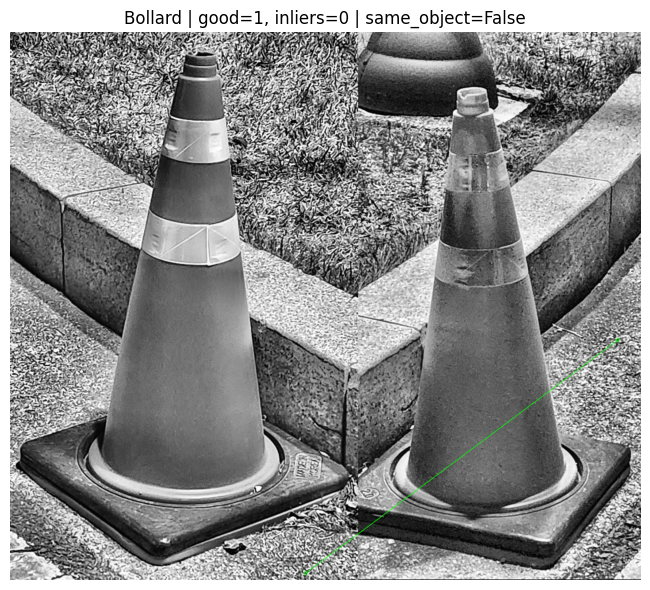

{'inliers': 0,
 'good_matches': 1,
 'total_kp1': 3001,
 'total_kp2': 3000,
 'homography': None,
 'match_obj': [< cv2.DMatch 0x7638f3f419d0>]}

In [90]:
visualize_match_crops(
    "/home/piai/바탕화면/원본/1_정방향.jpg",
    "/home/piai/바탕화면/원본/1_정방향2.jpg"
)

In [ ]:
# # 모든 신고 상세 조회
# with db_connect() as conn:
#     rows = conn.execute("""
#         SELECT report_id, group_id, facility_type, status, 
#                detection_conf, is_representative, image_path
#         FROM reports
#         ORDER BY report_id
#     """).fetchall()
    
#     for r in rows:
#         rep_marker = "★" if r['is_representative'] else " "
#         print(f"{rep_marker} report_{r['report_id']:03d} | group {r['group_id']} | "
#               f"{r['facility_type']:<15} | {r['status']:<8} | "
#               f"conf={r['detection_conf']:.2f} | {Path(r['image_path']).name}")

## 맨홀은 잘함

In [92]:
result = process_new_report("/home/piai/바탕화면/원본/7_정방향.jpg")
print(result)

[YOLO] Manhole_Normal (conf=0.96, bbox=(718, 1369, 2361, 2667))
[SIFT] 크롭 영역에서 3000개 특징점 추출
[DB] Manhole 타입 기존 그룹 0개
[NEW GROUP] facility_type=Manhole, group_id=3
{'status': 'accepted', 'report_id': 3, 'group_id': 3, 'facility_type': 'Manhole', 'detection_status': 'Normal', 'detection_conf': 0.9638141989707947, 'is_new_group': True, 'best_inliers': 0, 'matched_report_id': None}


In [93]:
result = process_new_report("/home/piai/바탕화면/원본/7_정방향2.jpg")
print(result)

[YOLO] Manhole_Normal (conf=0.96, bbox=(787, 1387, 2466, 2728))
[SIFT] 크롭 영역에서 3000개 특징점 추출
[DB] Manhole 타입 기존 그룹 1개
  vs report_0003 (group 3): good=118, inliers=92
[MATCH] group_id=3 (inliers=92)
{'status': 'accepted', 'report_id': 4, 'group_id': 3, 'facility_type': 'Manhole', 'detection_status': 'Normal', 'detection_conf': 0.9625600576400757, 'is_new_group': False, 'best_inliers': 92, 'matched_report_id': 3}


이미지1: Manhole_Normal (conf=0.96)
이미지2: Manhole_Normal (conf=0.96)


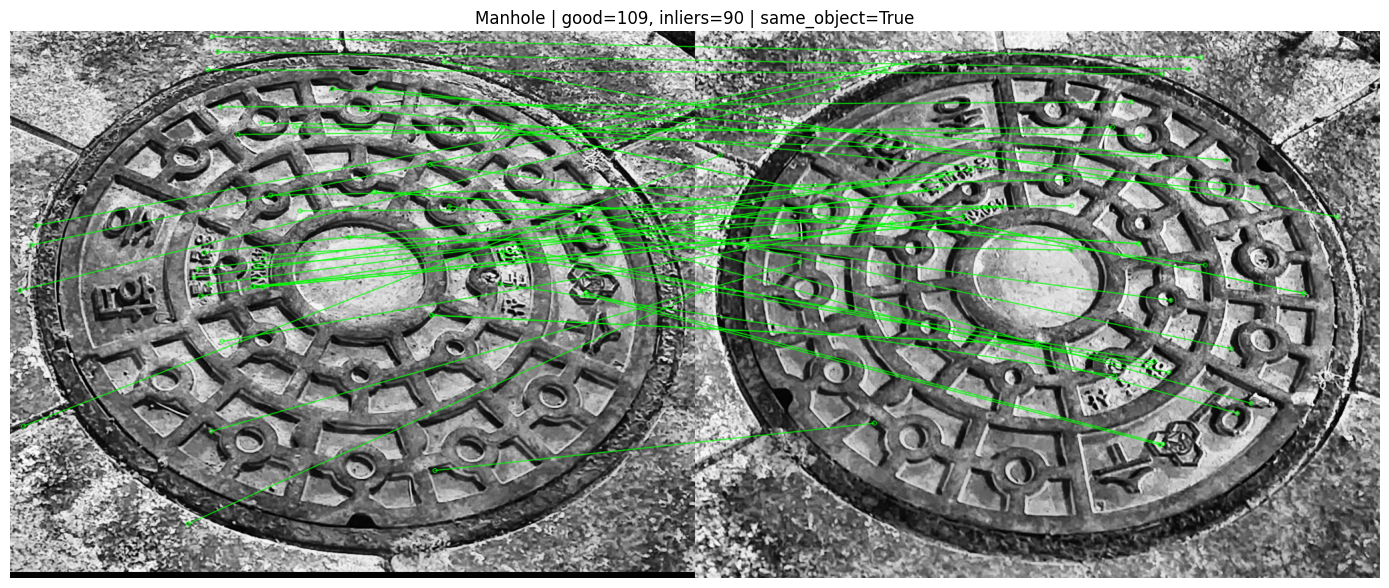

{'inliers': 90,
 'good_matches': 109,
 'total_kp1': 3000,
 'total_kp2': 3000,
 'homography': array([[    0.45771,    -0.93693,      580.96],
        [    0.52816,     0.53179,     -125.61],
        [-0.00021261,  0.00013616,           1]]),
 'match_obj': [< cv2.DMatch 0x7638f3f704f0>,
  < cv2.DMatch 0x7638f3f73f90>,
  < cv2.DMatch 0x7638f3f73f50>,
  < cv2.DMatch 0x7638f3f736b0>,
  < cv2.DMatch 0x7638f3f731f0>,
  < cv2.DMatch 0x7638f3f72ff0>,
  < cv2.DMatch 0x7638f3f72d90>,
  < cv2.DMatch 0x7638f3f72a50>,
  < cv2.DMatch 0x7638f3f723b0>,
  < cv2.DMatch 0x7638f3f72330>,
  < cv2.DMatch 0x7638f60b8f70>,
  < cv2.DMatch 0x7638f60ba470>,
  < cv2.DMatch 0x7638f60b9f70>,
  < cv2.DMatch 0x7638f60e8ab0>,
  < cv2.DMatch 0x7638f60e9270>,
  < cv2.DMatch 0x7638f60e9550>,
  < cv2.DMatch 0x7638f60e9650>,
  < cv2.DMatch 0x7638f60e9f70>,
  < cv2.DMatch 0x7638f60ea470>,
  < cv2.DMatch 0x7638f60eb770>,
  < cv2.DMatch 0x7638f60ebeb0>,
  < cv2.DMatch 0x7638f60ebf90>,
  < cv2.DMatch 0x7638f3f40650>,
  < cv2.DM

In [94]:
visualize_match_crops(
    "/home/piai/바탕화면/원본/7_정방향.jpg",
    "/home/piai/바탕화면/원본/7_정방향2.jpg"
)

In [95]:
result = process_new_report("/home/piai/바탕화면/원본/7_반대.jpg")
print(result)

[YOLO] Manhole_Normal (conf=0.97, bbox=(770, 1463, 2235, 2544))
[SIFT] 크롭 영역에서 3001개 특징점 추출
[DB] Manhole 타입 기존 그룹 1개
  vs report_0003 (group 3): good=39, inliers=15
[MATCH] group_id=3 (inliers=15)
{'status': 'accepted', 'report_id': 5, 'group_id': 3, 'facility_type': 'Manhole', 'detection_status': 'Normal', 'detection_conf': 0.9677262306213379, 'is_new_group': False, 'best_inliers': 15, 'matched_report_id': 3}


이미지1: Manhole_Normal (conf=0.96)
이미지2: Manhole_Normal (conf=0.97)


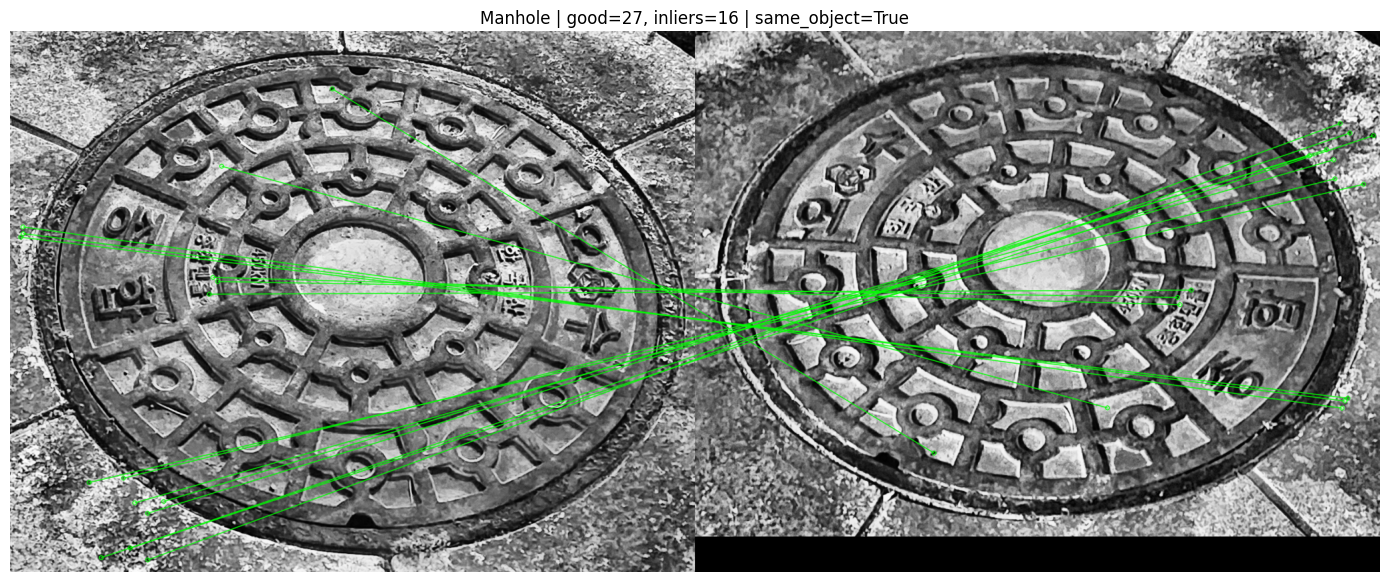

{'inliers': 16,
 'good_matches': 27,
 'total_kp1': 3000,
 'total_kp2': 3001,
 'homography': array([[    -1.1839,       1.219,      857.33],
        [   -0.35765,    -0.80588,      935.73],
        [ 6.2802e-05,  0.00078994,           1]]),
 'match_obj': [< cv2.DMatch 0x7638f3f43190>,
  < cv2.DMatch 0x7638f3f7d730>,
  < cv2.DMatch 0x7638f3f60670>,
  < cv2.DMatch 0x7638f3f63e30>,
  < cv2.DMatch 0x7638f3f61030>,
  < cv2.DMatch 0x7638f3f3ae10>,
  < cv2.DMatch 0x7638f3f38b50>,
  < cv2.DMatch 0x7638f3f392f0>,
  < cv2.DMatch 0x7638f3f66570>,
  < cv2.DMatch 0x7638f3f67cd0>,
  < cv2.DMatch 0x7638f3f4e270>,
  < cv2.DMatch 0x7638f3f4e2b0>,
  < cv2.DMatch 0x7638f3f4e3b0>,
  < cv2.DMatch 0x7638f3f4fb90>,
  < cv2.DMatch 0x7638f3f50cb0>,
  < cv2.DMatch 0x7638f3f51830>,
  < cv2.DMatch 0x7638f60bad30>,
  < cv2.DMatch 0x7638f3fd0870>,
  < cv2.DMatch 0x7638f3fd0b90>,
  < cv2.DMatch 0x7638f3fd14d0>,
  < cv2.DMatch 0x7638f3fd2550>,
  < cv2.DMatch 0x7638f60ea5d0>,
  < cv2.DMatch 0x7638f60ebc70>,
  < cv2.DMa

In [96]:
visualize_match_crops(
    "/home/piai/바탕화면/원본/7_정방향.jpg",
    "/home/piai/바탕화면/원본/7_반대.jpg"
)

In [97]:
result = process_new_report("/home/piai/바탕화면/원본/7_other.jpg")
print(result)

[YOLO] Manhole_Normal (conf=0.96, bbox=(693, 1358, 2382, 2631))
[SIFT] 크롭 영역에서 3000개 특징점 추출
[DB] Manhole 타입 기존 그룹 1개
  vs report_0003 (group 3): good=12, inliers=5
[NEW GROUP] facility_type=Manhole, group_id=4
{'status': 'accepted', 'report_id': 6, 'group_id': 4, 'facility_type': 'Manhole', 'detection_status': 'Normal', 'detection_conf': 0.9641099572181702, 'is_new_group': True, 'best_inliers': 5, 'matched_report_id': None}


## 등받이 없는 벤치

In [98]:
result = process_new_report("/home/piai/바탕화면/원본/6_정방향.jpg")
print(result)

[YOLO] BenchWithoutBack_Normal (conf=0.95, bbox=(274, 1353, 2644, 3423))
[SIFT] 크롭 영역에서 3000개 특징점 추출
[DB] BenchWithoutBack 타입 기존 그룹 0개
[NEW GROUP] facility_type=BenchWithoutBack, group_id=5
{'status': 'accepted', 'report_id': 7, 'group_id': 5, 'facility_type': 'BenchWithoutBack', 'detection_status': 'Normal', 'detection_conf': 0.9467542171478271, 'is_new_group': True, 'best_inliers': 0, 'matched_report_id': None}


In [99]:
result = process_new_report("/home/piai/바탕화면/원본/6_정방향2.jpg")
print(result)

[YOLO] BenchWithoutBack_Normal (conf=0.98, bbox=(246, 1554, 2975, 3137))
[SIFT] 크롭 영역에서 3001개 특징점 추출
[DB] BenchWithoutBack 타입 기존 그룹 1개
  vs report_0007 (group 5): good=30, inliers=23
[MATCH] group_id=5 (inliers=23)
{'status': 'accepted', 'report_id': 8, 'group_id': 5, 'facility_type': 'BenchWithoutBack', 'detection_status': 'Normal', 'detection_conf': 0.9765132069587708, 'is_new_group': False, 'best_inliers': 23, 'matched_report_id': 7}


이미지1: BenchWithoutBack_Normal (conf=0.95)
이미지2: BenchWithoutBack_Normal (conf=0.98)


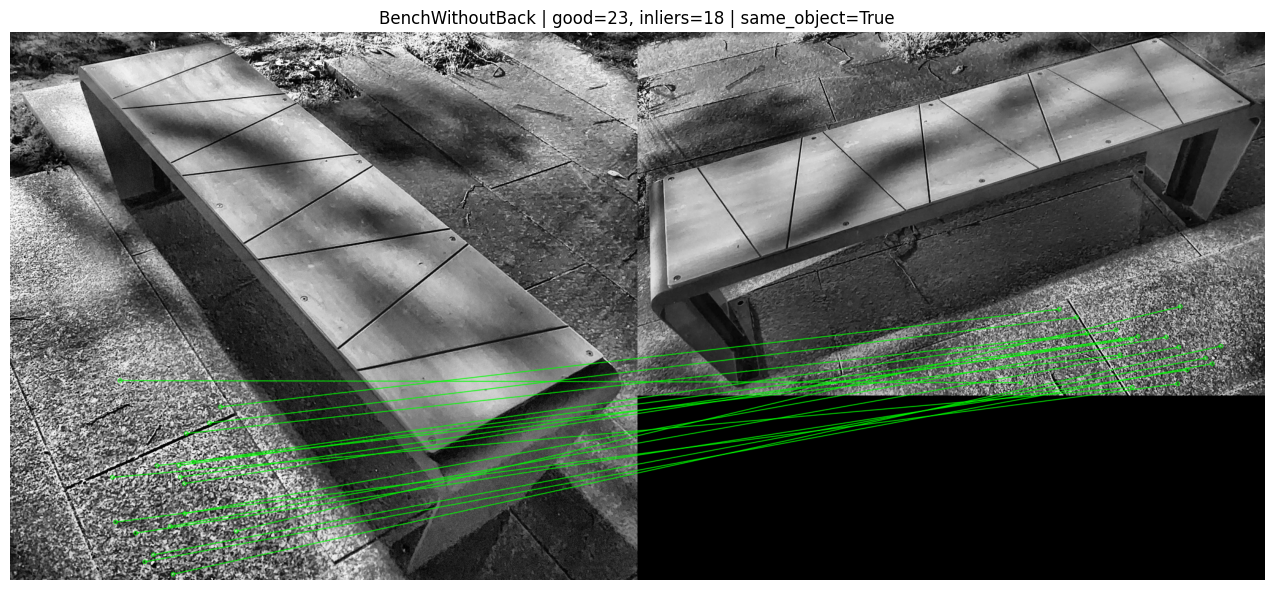

{'inliers': 18,
 'good_matches': 23,
 'total_kp1': 3000,
 'total_kp2': 3001,
 'homography': array([[      0.929,      3.2689,     -812.33],
        [    -0.9104,      0.7035,      870.44],
        [    0.00118,   0.0012783,           1]]),
 'match_obj': [< cv2.DMatch 0x7638f61f9590>,
  < cv2.DMatch 0x7638f3f64070>,
  < cv2.DMatch 0x7638f3f652b0>,
  < cv2.DMatch 0x7638f3f4f170>,
  < cv2.DMatch 0x7638f3f52930>,
  < cv2.DMatch 0x7638f3f52b50>,
  < cv2.DMatch 0x7638f3f53410>,
  < cv2.DMatch 0x7638f3f535d0>,
  < cv2.DMatch 0x7638f3fd0450>,
  < cv2.DMatch 0x7638f3fd1c10>,
  < cv2.DMatch 0x7638f3fd26b0>,
  < cv2.DMatch 0x7638f60eb170>,
  < cv2.DMatch 0x7638f60eb550>,
  < cv2.DMatch 0x7638f3f71470>,
  < cv2.DMatch 0x7638f3f601d0>,
  < cv2.DMatch 0x7638f3f63290>,
  < cv2.DMatch 0x7638f3f61b50>,
  < cv2.DMatch 0x7638f3f7e270>,
  < cv2.DMatch 0x7638f3f38db0>,
  < cv2.DMatch 0x7638f3f43e50>,
  < cv2.DMatch 0x7638f3f57d10>,
  < cv2.DMatch 0x7638f3f555b0>,
  < cv2.DMatch 0x7638f3f560f0>]}

In [100]:
visualize_match_crops(
    "/home/piai/바탕화면/원본/6_정방향.jpg",
    "/home/piai/바탕화면/원본/6_정방향2.jpg"
)

In [101]:
result = process_new_report("/home/piai/바탕화면/원본/6_other.jpg")
print(result)

[YOLO] BenchWithoutBack_Normal (conf=0.91, bbox=(177, 1205, 2610, 3454))
[SIFT] 크롭 영역에서 3000개 특징점 추출
[DB] BenchWithoutBack 타입 기존 그룹 1개
  vs report_0007 (group 5): good=7, inliers=4
[NEW GROUP] facility_type=BenchWithoutBack, group_id=6
{'status': 'accepted', 'report_id': 9, 'group_id': 6, 'facility_type': 'BenchWithoutBack', 'detection_status': 'Normal', 'detection_conf': 0.9103061556816101, 'is_new_group': True, 'best_inliers': 4, 'matched_report_id': None}


In [ ]:
### 이게 문제임

result = process_new_report("/home/piai/바탕화면/원본/6_반대.jpg")
print(result)

[YOLO] BenchWithoutBack_Normal (conf=0.97, bbox=(303, 1438, 2767, 3272))
[SIFT] 크롭 영역에서 3000개 특징점 추출
[DB] BenchWithoutBack 타입 기존 그룹 2개
  vs report_0007 (group 5): good=2, inliers=0
  vs report_0009 (group 6): good=10, inliers=4
[NEW GROUP] facility_type=BenchWithoutBack, group_id=7
{'status': 'accepted', 'report_id': 10, 'group_id': 7, 'facility_type': 'BenchWithoutBack', 'detection_status': 'Normal', 'detection_conf': 0.9702194929122925, 'is_new_group': True, 'best_inliers': 4, 'matched_report_id': None}


이미지1: BenchWithoutBack_Normal (conf=0.95)
이미지2: BenchWithoutBack_Normal (conf=0.97)


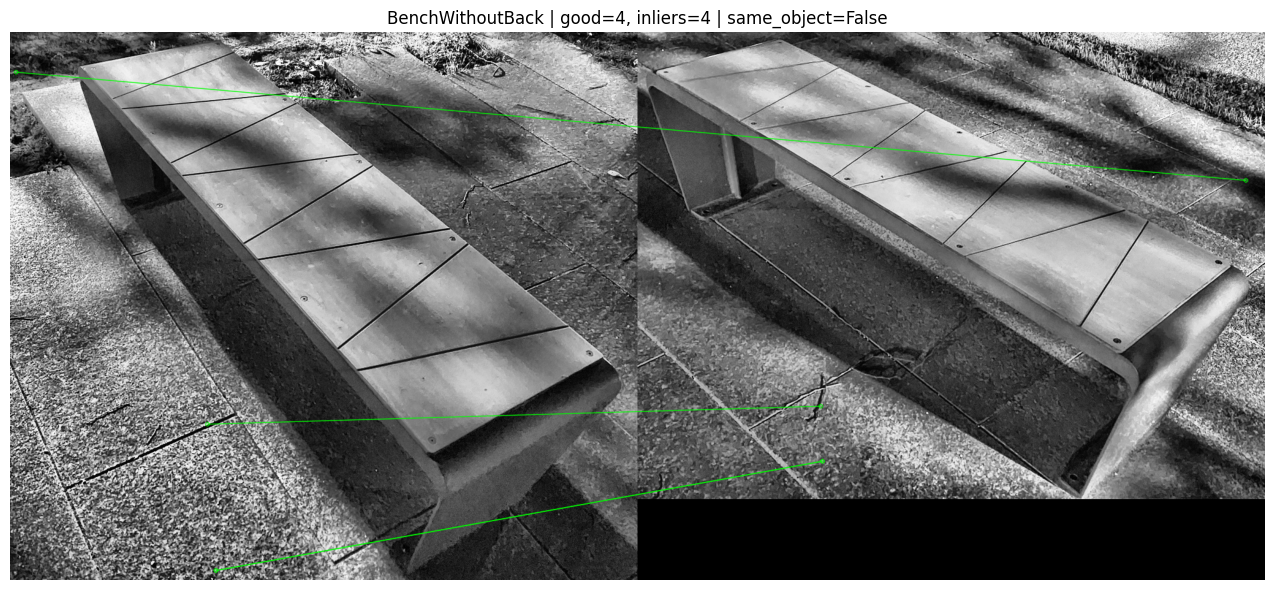

{'inliers': 4,
 'good_matches': 4,
 'total_kp1': 3000,
 'total_kp2': 3000,
 'homography': array([[    -9.2517,      2.2053,      1179.6],
        [    -10.962,      4.0576,       141.4],
        [  -0.020618,   0.0067831,           1]]),
 'match_obj': [< cv2.DMatch 0x7638f3fd0f70>,
  < cv2.DMatch 0x7638f60270f0>,
  < cv2.DMatch 0x7638f6026ef0>,
  < cv2.DMatch 0x7638f3f3a930>]}

In [103]:
visualize_match_crops(
    "/home/piai/바탕화면/원본/6_정방향.jpg",
    "/home/piai/바탕화면/원본/6_반대.jpg"
)

## 트렌치

In [104]:
result = process_new_report("/home/piai/바탕화면/원본/5_other.jpg")
print(result)

[YOLO] Trench_Normal (conf=0.90, bbox=(845, -11, 2325, 3897))
[SIFT] 크롭 영역에서 3000개 특징점 추출
[DB] Trench 타입 기존 그룹 0개
[NEW GROUP] facility_type=Trench, group_id=8
{'status': 'accepted', 'report_id': 11, 'group_id': 8, 'facility_type': 'Trench', 'detection_status': 'Normal', 'detection_conf': 0.8976383209228516, 'is_new_group': True, 'best_inliers': 0, 'matched_report_id': None}


In [107]:
result = process_new_report("/home/piai/바탕화면/원본/5_정방향2.jpg")
print(result)

[REJECTED] 물체를 찾지 못했습니다.
{'status': 'rejected', 'reason': 'object_not_detected'}


맨홀...?

In [108]:
result = process_new_report("/home/piai/바탕화면/원본/4_other.jpg")
print(result)

[YOLO] BenchWithBack_Normal (conf=0.57, bbox=(410, 1388, 2555, 3194))
[SIFT] 크롭 영역에서 3001개 특징점 추출
[DB] BenchWithBack 타입 기존 그룹 0개
[NEW GROUP] facility_type=BenchWithBack, group_id=9
{'status': 'accepted', 'report_id': 12, 'group_id': 9, 'facility_type': 'BenchWithBack', 'detection_status': 'Normal', 'detection_conf': 0.5665270686149597, 'is_new_group': True, 'best_inliers': 0, 'matched_report_id': None}


In [109]:
result = process_new_report("/home/piai/바탕화면/원본/4_반대.jpg")
print(result)

[YOLO] BenchWithoutBack_Normal (conf=0.40, bbox=(617, 1596, 2479, 2843))
[SIFT] 크롭 영역에서 3000개 특징점 추출
[DB] BenchWithoutBack 타입 기존 그룹 3개
  vs report_0007 (group 5): good=1, inliers=0
  vs report_0009 (group 6): good=5, inliers=0
  vs report_0010 (group 7): good=5, inliers=0
[NEW GROUP] facility_type=BenchWithoutBack, group_id=10
{'status': 'accepted', 'report_id': 13, 'group_id': 10, 'facility_type': 'BenchWithoutBack', 'detection_status': 'Normal', 'detection_conf': 0.4044647216796875, 'is_new_group': True, 'best_inliers': 0, 'matched_report_id': None}


In [111]:
result = process_new_report("/home/piai/바탕화면/원본/4_정방향2.jpg")
print(result)

[REJECTED] 물체를 찾지 못했습니다.
{'status': 'rejected', 'reason': 'object_not_detected'}


In [112]:
print_db_status()

 gid | facility_type          | count |  dmg | created_at
---------------------------------------------------------------------------
   1 | Bollard                |     1 |    0 | 2026-04-23 13:44:19
   2 | Bollard                |     1 |    1 | 2026-04-23 13:45:41
   3 | Manhole                |     3 |    0 | 2026-04-23 13:48:59
   4 | Manhole                |     1 |    0 | 2026-04-23 13:50:48
   5 | BenchWithoutBack       |     2 |    0 | 2026-04-23 13:51:29
   6 | BenchWithoutBack       |     1 |    0 | 2026-04-23 13:52:25
   7 | BenchWithoutBack       |     1 |    0 | 2026-04-23 13:52:50
   8 | Trench                 |     1 |    0 | 2026-04-23 13:54:06
   9 | BenchWithBack          |     1 |    0 | 2026-04-23 13:55:12
  10 | BenchWithoutBack       |     1 |    0 | 2026-04-23 13:55:39

총 그룹: 10개, 총 신고: 13건


# 새로운 이미지

In [56]:
from pathlib import Path

p = Path("/home/piai/바탕화면/원본/정방향(1).jpg")
print("존재 여부:", p.exists())
print("절대경로:", p.resolve() if p.exists() else "파일 없음")

# 폴더 안 실제 파일 목록
folder = Path("/home/piai/바탕화면/원본")
print("\n폴더 존재:", folder.exists())
if folder.exists():
    print("폴더 안 파일들:")
    for f in folder.iterdir():
        print(f"  '{f.name}'")  # 따옴표로 감싸서 공백 확인

존재 여부: True
절대경로: /home/piai/바탕화면/원본/정방향(1).jpg

폴더 존재: True
폴더 안 파일들:
  '4_정방향.jpg'
  '반대1.jpg'
  '6_정방향2.jpg'
  '2_반대.jpg'
  '1_other.jpg'
  '6_other.jpg'
  '6_반대.jpg'
  '5_반대.jpg'
  '7_other.jpg'
  '5_other.jpg'
  '정방향1.jpg'
  '7_반대.jpg'
  '1_정방향2.jpg'
  '5_정방향.jpg'
  '6_정방향.jpg'
  '1_정방향.jpg'
  '7_정방향2.jpg'
  '4_정방향2.jpg'
  '7_정방향.jpg'
  '반대(2).jpg'
  '정방향(2).jpg'
  '2_정방향2.jpg'
  '1_반대.jpg'
  '2_정방향.jpg'
  '4_other.jpg'
  '정방향(1).jpg'
  '반대(1).jpg'
  '5_정방향2.jpg'
  '2_other.jpg'
  '정방향2.jpg'
  '4_반대.jpg'


In [58]:
from pathlib import Path
import os

p = "/home/piai/바탕화면/원본/정방향_1.jpg"

print("1. exists():", Path(p).exists())
print("2. os.path.exists:", os.path.exists(p))
print("3. realpath:", os.path.realpath(p))
print("4. abspath:", os.path.abspath(p))

# 파일 직접 열기 테스트
try:
    with open(p, "rb") as f:
        print("5. 파일 열기 OK, 크기:", len(f.read()))
except Exception as e:
    print("5. 파일 열기 실패:", e)

1. exists(): True
2. os.path.exists: True
3. realpath: /home/piai/바탕화면/원본/정방향_1.jpg
4. abspath: /home/piai/바탕화면/원본/정방향_1.jpg
5. 파일 열기 OK, 크기: 4111766


In [57]:
result = process_new_report("/home/piai/바탕화면/원본/정방향_1.jpg")
print(result)

FileNotFoundError: [Errno 2] No such file or directory

In [ ]:
result = process_new_report("/home/piai/바탕화면/원본/정방향(2).jpg")
print(result)

[YOLO] Bollard_Normal (conf=0.94, bbox=(1259, 1734, 1643, 3198))
[SIFT] 크롭 영역에서 3000개 특징점 추출
[DB] Bollard 타입 기존 그룹 1개
  vs report_0001 (group 1): good=47, inliers=16
[MATCH] group_id=1 (inliers=16)
{'status': 'accepted', 'report_id': 2, 'group_id': 1, 'facility_type': 'Bollard', 'detection_status': 'Normal', 'detection_conf': 0.9410563111305237, 'is_new_group': False, 'best_inliers': 16, 'matched_report_id': 1}


이미지1: Bollard_Normal (conf=0.93)
이미지2: Bollard_Normal (conf=0.94)


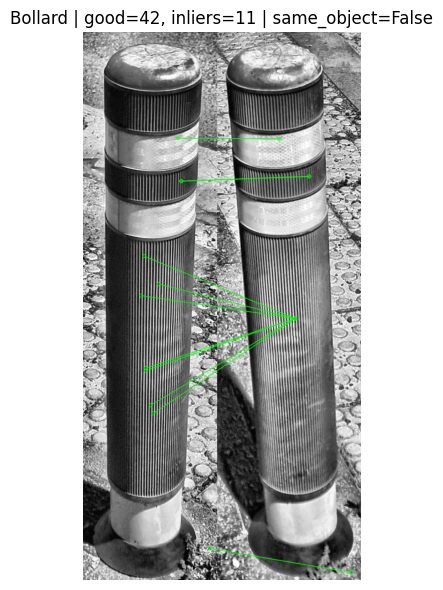

{'inliers': 11,
 'good_matches': 42,
 'total_kp1': 3000,
 'total_kp2': 3000,
 'homography': array([[    -0.8989,    0.069681,      144.63],
        [    -3.3224,     0.25742,      534.71],
        [ -0.0062138,  0.00048132,           1]]),
 'match_obj': [< cv2.DMatch 0x7a1a79067250>,
  < cv2.DMatch 0x7a1a79066c70>,
  < cv2.DMatch 0x7a1a7922be10>,
  < cv2.DMatch 0x7a1a790771f0>,
  < cv2.DMatch 0x7a1a79074c50>,
  < cv2.DMatch 0x7a1a79077930>,
  < cv2.DMatch 0x7a1a790754f0>,
  < cv2.DMatch 0x7a1a79074af0>,
  < cv2.DMatch 0x7a1a78fed9b0>,
  < cv2.DMatch 0x7a1a785051d0>,
  < cv2.DMatch 0x7a1a7850b830>,
  < cv2.DMatch 0x7a1a7850aaf0>,
  < cv2.DMatch 0x7a1a7850aff0>,
  < cv2.DMatch 0x7a1a7850b570>,
  < cv2.DMatch 0x7a1a79058830>,
  < cv2.DMatch 0x7a1a79058870>,
  < cv2.DMatch 0x7a1a79058730>,
  < cv2.DMatch 0x7a1a7905bf70>,
  < cv2.DMatch 0x7a1a7905b870>,
  < cv2.DMatch 0x7a1a7905b9d0>,
  < cv2.DMatch 0x7a1a7905b250>,
  < cv2.DMatch 0x7a1a79059db0>,
  < cv2.DMatch 0x7a1a79059c30>,
  < cv2.DMa

In [ ]:
visualize_match_crops(
    "/home/piai/바탕화면/원본/정방향(1).jpg",
    "/home/piai/바탕화면/원본/정방향(2).jpg"
)

In [ ]:
result = process_new_report("/home/piai/바탕화면/원본/반대(1).jpg")
print(result)

[YOLO] Bollard_Normal (conf=0.92, bbox=(1412, 1847, 1786, 3446))
[SIFT] 크롭 영역에서 3001개 특징점 추출
[DB] Bollard 타입 기존 그룹 1개
  vs report_0001 (group 1): good=13, inliers=5
[NEW GROUP] facility_type=Bollard, group_id=2
{'status': 'accepted', 'report_id': 3, 'group_id': 2, 'facility_type': 'Bollard', 'detection_status': 'Normal', 'detection_conf': 0.9224488735198975, 'is_new_group': True, 'best_inliers': 5, 'matched_report_id': None}


In [44]:
result = process_new_report("/home/piai/바탕화면/원본/반대(2).jpg")
print(result)

FileNotFoundError: [Errno 2] No such file or directory